# NB_03 — Evaluate Agents

This notebook applies LLM-based evaluation to the agent outputs produced in NB_02 and aggregates scores per architecture. All metrics are computed by Arize Phoenix using GPT-5 as the judge and return a float in **[0.0, 1.0]**.

## Section overview

1. **Resolve the latest raw run** — locate the most recent `runner_results_*.jsonl` artifact
2. **Inspect the prepared evaluation frame** — preview answers, contexts, and expected answers
3. **Run overall Phoenix evaluation** — score all runs across all metric families
4. **Review metric tables and score distributions** — per-architecture averages and score bar charts

## Evaluation framework

| Family | Metric | Definition |
|---|---|---|
| Answer quality | **Faithfulness** | Is every claim grounded in the retrieved context? Penalises hallucinated statements. |
| Answer quality | **Conciseness** | Does the answer stay focused without unnecessary padding? |
| Answer quality | **Correctness** | Does the answer match the reference answer from the question set? |
| Retrieval quality | **Document relevance** | Are the retrieved documents relevant to the question? Averaged per run. |
| Tool quality | **Tool selection** | Did the agent choose the right tools in the right order? |
| Tool quality | **Tool invocation** | Were the tool arguments well-formed and appropriate for the question? |

## Prerequisites

- NB_02 completed (raw results in `data/evaluation/results/`)
- Phoenix running: `docker compose up -d phoenix`
- OpenAI API key in `.env`

Run cells from top to bottom.

In [23]:
import sys
from pathlib import Path

# Ensure project root is on the Python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Step 1: Resolve the latest raw run

Finds the most recent `runner_results_*.jsonl` artifact in `data/evaluation/results/` and extracts the `RUN_ID` that links it to all downstream evaluation files.

In [24]:
import logging
import warnings

warnings.filterwarnings("ignore")

import structlog
import pandas as pd

from sources.config import config as app_config
from sources.evaluator import Evaluator
from sources.observer import init_tracing

ARTIFACT_PREFIX = "overall"

structlog.configure(
    wrapper_class=structlog.make_filtering_bound_logger(logging.INFO),
)
logger = structlog.get_logger(__name__)

init_tracing()

evaluator = Evaluator(
    results_dir=app_config.paths.results_dir,
    concurrency=app_config.concurrency.max_workers,
    model_name=app_config.llm.model_for_role("evaluation"),
)

RESULTS_PATH = evaluator.latest_results_path()
RUN_ID = RESULTS_PATH.stem.replace("runner_results_", "")

logger.info(
    "phoenix_eval_setup",
    results_path=str(RESULTS_PATH),
    run_id=RUN_ID,
    concurrency=evaluator.concurrency,
    model=evaluator.model_name,
    artifact_prefix=ARTIFACT_PREFIX,
    answer_score_cols=app_config.evaluation.answer_score_cols,
    tool_score_cols=app_config.evaluation.tool_score_cols,
)

2026-05-16 18:09:42 [info     ] tracing_already_initialized   
2026-05-16 18:09:42 [info     ] phoenix_eval_setup             answer_score_cols=['phoenix_faithfulness_score', 'phoenix_conciseness_score', 'phoenix_correctness_score'] artifact_prefix=overall concurrency=32 model=gpt-5 results_path=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/evaluation/results/runner_results_20260313_200511.jsonl run_id=20260313_200511 tool_score_cols=['phoenix_tool_selection_score', 'phoenix_tool_invocation_score']


## Step 2: Inspect the prepared evaluation frame

Loads the raw results, attaches pre-computed evaluation columns, and displays a preview of the first ten rows to confirm that answers, contexts, and expected answers are all present.

In [25]:
loaded_run_id, loaded_results_path, prepared_df = evaluator.load_results(RESULTS_PATH)

assert loaded_run_id == RUN_ID
assert loaded_results_path == RESULTS_PATH

preview_cols = [
    col
    for col in [
        "row_id",
        "question",
        "pattern_name",
        "has_answer",
        "has_expected_answer",
        "has_context",
        "tool_count",
        "citation_count",
    ]
    if col in prepared_df.columns
]

logger.info(
    "evaluation_frame_loaded",
    rows=len(prepared_df),
    patterns=sorted(prepared_df["pattern_name"].dropna().unique().tolist()),
    preview_rows=prepared_df[preview_cols]
    .head(10)
    .fillna("")
    .to_dict(orient="records"),
)

display(prepared_df[preview_cols].head(10))

2026-05-16 18:09:42 [info     ] evaluation_frame_loaded        patterns=['blackboard', 'deterministic', 'hierarchical', 'planner_executor', 'react', 'router_specialist'] preview_rows=[{'row_id': 0, 'question': 'Ile wariantów ubezpieczenia oferuje ERGO Podróż?', 'pattern_name': 'blackboard', 'has_answer': True, 'has_expected_answer': True, 'has_context': True, 'tool_count': 10, 'citation_count': 4}, {'row_id': 1, 'question': 'Czy i do jakiej kwoty w ubezpieczeniu ERGO Podróż pokrywane są koszty pomocy stomatologicznej?', 'pattern_name': 'blackboard', 'has_answer': True, 'has_expected_answer': True, 'has_context': True, 'tool_count': 10, 'citation_count': 4}, {'row_id': 2, 'question': 'Ile wariantów ubezpieczenia oferuje ERGO Podróż?', 'pattern_name': 'planner_executor', 'has_answer': True, 'has_expected_answer': True, 'has_context': True, 'tool_count': 7, 'citation_count': 4}, {'row_id': 3, 'question': 'Czy mogę dowolnie ustalić wysokość sumy ubezpieczenia Kosztów Leczenia w ERGO Podróż

,row_id,question,pattern_name,has_answer,has_expected_answer,has_context,tool_count,citation_count
0,0,Ile wariantów ubezpieczenia oferuje ERGO Podróż?,blackboard,True,True,True,10,4
1,1,Czy i do jakiej kwoty w ubezpieczeniu ERGO Pod...,blackboard,True,True,True,10,4
2,2,Ile wariantów ubezpieczenia oferuje ERGO Podróż?,planner_executor,True,True,True,7,4
3,3,Czy mogę dowolnie ustalić wysokość sumy ubezpi...,planner_executor,True,True,True,7,4
4,4,Ile wariantów ubezpieczenia oferuje ERGO Podróż?,router_specialist,True,True,True,10,4
5,5,Czy i do jakiej kwoty w ubezpieczeniu ERGO Pod...,router_specialist,True,True,True,10,4
6,6,Czy w ERGO Podróże może zostać zawarta umowa g...,planner_executor,True,True,True,7,4
7,7,Czy w ERGO Podróże może zostać zawarta umowa g...,hierarchical,True,True,True,159,4
8,8,Czy i do jakiej kwoty w ubezpieczeniu ERGO Pod...,deterministic,True,True,True,10,4
9,9,Ile wariantów ubezpieczenia oferuje ERGO Podróż?,deterministic,True,True,True,10,4


## Step 3: Run overall Phoenix evaluation

Sends the prepared frame to the Phoenix evaluator for LLM-judge scoring across all metric families. If evaluation artifacts already exist for this `RUN_ID` they are loaded from disk and the LLM calls are skipped.

In [26]:
# Skip-if-exists: if evaluation artifacts from a previous run already
# exist on disk, load them directly and skip the Phoenix LLM judge.

_existing_summary = sorted(
    app_config.paths.results_dir.glob(f"{ARTIFACT_PREFIX}_summary_*.csv"),
    reverse=True,
)
_EVAL_EXISTS = bool(_existing_summary)

if _EVAL_EXISTS:
    _summary_path = _existing_summary[0]
    _eval_run_id = _summary_path.stem.replace(f"{ARTIFACT_PREFIX}_summary_", "")
    logger.info(
        "evaluation_already_exists_skipping",
        summary_path=str(_summary_path),
        run_id=_eval_run_id,
    )

    _answer_path = (
        app_config.paths.results_dir
        / f"{ARTIFACT_PREFIX}_answer_metrics_{_eval_run_id}.csv"
    )
    _doc_path = (
        app_config.paths.results_dir
        / f"{ARTIFACT_PREFIX}_document_relevance_{_eval_run_id}.csv"
    )

    _phoenix_summary_df = pd.read_csv(_summary_path)
    _answer_metric_df = (
        pd.read_csv(_answer_path) if _answer_path.exists() else pd.DataFrame()
    )
    _doc_metric_df = pd.read_csv(_doc_path) if _doc_path.exists() else pd.DataFrame()

    # Reconstruct the artifacts dict used by downstream cells
    artifacts = {
        "phoenix_summary_df": _phoenix_summary_df,
        "phoenix_summary_path": _summary_path,
        "answer_metric_df": _answer_metric_df,
        "answer_metric_path": _answer_path,
        "document_metric_df": _doc_metric_df,
        "document_metric_path": _doc_path,
        "tool_metric_df": pd.DataFrame(),
        "tool_metric_path": app_config.paths.results_dir
        / f"{ARTIFACT_PREFIX}_tool_metrics_{_eval_run_id}.csv",
    }

    # Derive per-architecture answer summary for display
    _ans_score_cols = [
        c
        for c in app_config.evaluation.answer_score_cols
        if c in _answer_metric_df.columns
    ]
    if _ans_score_cols and not _answer_metric_df.empty:
        artifacts["answer_summary_df"] = (
            _answer_metric_df.groupby("pattern_name")[_ans_score_cols]
            .mean()
            .reset_index()
        )
    else:
        artifacts["answer_summary_df"] = pd.DataFrame()

    _doc_score_cols = [
        c
        for c in app_config.evaluation.document_score_cols
        if c in _doc_metric_df.columns
    ]
    if _doc_score_cols and not _doc_metric_df.empty:
        artifacts["document_summary_df"] = (
            _doc_metric_df.groupby("pattern_name")[_doc_score_cols].mean().reset_index()
        )
    else:
        artifacts["document_summary_df"] = pd.DataFrame()

else:
    artifacts = await evaluator.evaluate(
        results_path=RESULTS_PATH,
        artifact_prefix=ARTIFACT_PREFIX,
    )

    _saved_paths = {
        "answer_metrics": artifacts["answer_metric_path"].name,
        "document_metrics": (
            artifacts["document_metric_path"].name
            if not artifacts["document_metric_df"].empty
            else "not generated"
        ),
        "summary": artifacts["phoenix_summary_path"].name,
    }
    logger.info("evaluation_complete", artifacts=_saved_paths)

display(artifacts["phoenix_summary_df"])

2026-05-16 18:09:42 [info     ] evaluation_already_exists_skipping run_id=20260313_200511 summary_path=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/evaluation/results/overall_summary_20260313_200511.csv


,pattern_name,phoenix_faithfulness_score,phoenix_conciseness_score,phoenix_correctness_score,phoenix_document_relevance_score
0,blackboard,0.788889,0.653333,0.633333,0.332344
1,deterministic,0.777778,0.631111,0.715556,0.364179
2,hierarchical,0.696629,0.676404,0.587640,0.344214
3,planner_executor,0.788889,0.653333,0.620000,0.348684
4,react,0.611111,0.682222,0.598889,0.363636
5,router_specialist,0.811111,0.644444,0.663333,0.357576


## Step 4: Review metric tables and score distributions

The tables below show per-architecture averages. The histograms reveal the score distribution across individual runs — a high mean with a long left tail indicates that most runs succeed but some questions fail for all architectures.

In [27]:
display(artifacts["answer_summary_df"])

,pattern_name,phoenix_faithfulness_score,phoenix_conciseness_score,phoenix_correctness_score
0,blackboard,0.788889,0.653333,0.633333
1,deterministic,0.777778,0.631111,0.715556
2,hierarchical,0.696629,0.676404,0.587640
3,planner_executor,0.788889,0.653333,0.620000
4,react,0.611111,0.682222,0.598889
5,router_specialist,0.811111,0.644444,0.663333


In [28]:
if not artifacts["document_summary_df"].empty:
    display(artifacts["document_summary_df"])

,pattern_name,phoenix_document_relevance_score
0,blackboard,0.332344
1,deterministic,0.364179
2,hierarchical,0.344214
3,planner_executor,0.348684
4,react,0.363636
5,router_specialist,0.357576


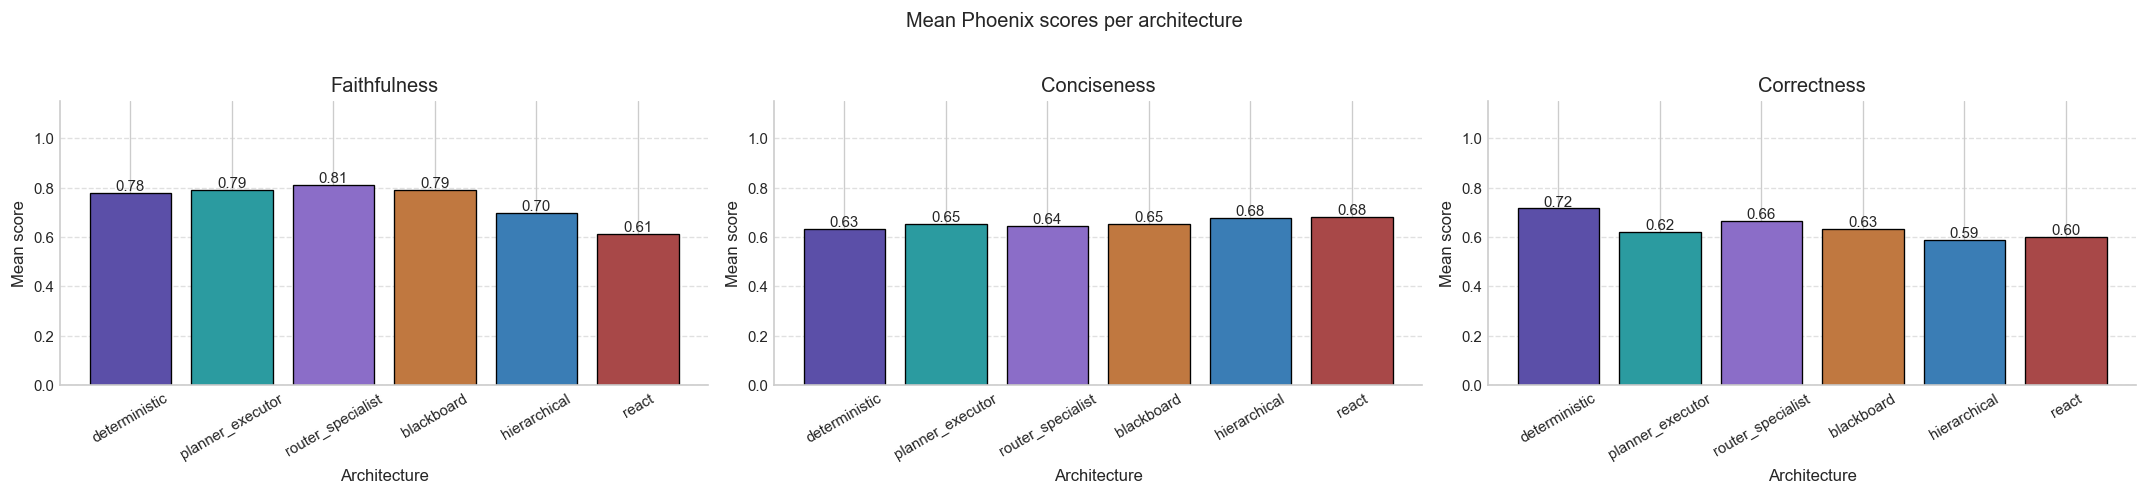


Null/incomplete rate per architecture (lower is better):


,phoenix_faithfulness_score,phoenix_conciseness_score,phoenix_correctness_score
pattern_name,,,
blackboard,0.0,0.0,0.0
deterministic,0.0,0.0,0.0
hierarchical,0.0,0.0,0.0
planner_executor,0.0,0.0,0.0
react,0.0,0.0,0.0
router_specialist,0.0,0.0,0.0


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.style as mstyle
import pandas as pd
import seaborn as sns

mstyle.use("seaborn-v0_8-whitegrid")

ARCH_COLORS = {
    "deterministic": "#5B4FA8",
    "planner_executor": "#2B9BA0",
    "router_specialist": "#8B6DC8",
    "blackboard": "#C07840",
    "hierarchical": "#3A7DB5",
    "react": "#A84848",
}
ARCH_ORDER = [
    "deterministic",
    "planner_executor",
    "router_specialist",
    "blackboard",
    "hierarchical",
    "react",
]

answer_df = artifacts.get("answer_metric_df", pd.DataFrame())
answer_score_cols = [
    c for c in app_config.evaluation.answer_score_cols if c in answer_df.columns
]

if not answer_df.empty and answer_score_cols:
    patterns = [
        p for p in ARCH_ORDER if p in answer_df["pattern_name"].dropna().unique()
    ]
    n_metrics = len(answer_score_cols)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 4), dpi=120)
    if n_metrics == 1:
        axes = [axes]

    for ax, metric in zip(axes, answer_score_cols):
        means = [
            answer_df.loc[answer_df["pattern_name"] == p, metric].mean()
            for p in patterns
        ]
        colors = [ARCH_COLORS.get(p, "#888888") for p in patterns]
        bars = ax.bar(patterns, means, color=colors, edgecolor="black", linewidth=0.8)
        for bar, val in zip(bars, means):
            if not pd.isna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    val + 0.01,
                    f"{val:.2f}",
                    ha="center",
                    fontsize=9,
                )
        ax.set_title(
            metric.replace("phoenix_", "")
            .replace("_score", "")
            .replace("_", " ")
            .title()
        )
        ax.set_xlabel("Architecture")
        ax.set_ylabel("Mean score")
        ax.set_ylim(0, 1.15)
        ax.tick_params(axis="x", rotation=30, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
        ax.set_axisbelow(True)
        sns.despine(ax=ax)

    plt.suptitle("Mean Phoenix scores per architecture", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

    # Null/incomplete rate per architecture
    null_rates = (
        answer_df.groupby("pattern_name")[answer_score_cols]
        .apply(lambda g: g.isna().mean())
        .round(3)
    )
    print("\nNull/incomplete rate per architecture (lower is better):")
    display(null_rates)
else:
    print("Answer metric data not available for distribution plots.")